<a href="https://colab.research.google.com/github/chiranjeevi-manike/Deep-Learning/blob/main/feedforward_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feedforward Neural Network with TensorFlow


## Step 1: Import Libraries
We need to import the necessary libraries for creating and training a neural network:
- **NumPy** – For handling numerical computations.
- **TensorFlow** – For building and training the neural network.
- **scikit-learn** – For data preprocessing and generating sample data.


In [ ]:

# Import Libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification


**layers**

* This module contains predefined layers used to construct neural networks.

**Examples**:

* layers.Dense – Fully connected (FC) layer (used in MLPs).

* layers.Conv2D – Convolutional layer (used in CNNs).

* layers.LSTM – Long Short-Term Memory layer (used in RNNs).

* layers.Dropout – Regularization technique to prevent overfitting.

* layers.BatchNormalization – Normalizes activations to improve training stability.

**models**

* This module is used to define and manage neural network models.

It provides two main types of models:

* models.Sequential – A simple stack of layers.

* models.Model – More flexible, for complex architectures (e.g., multi-input, multi-output models).


## Step 2: Prepare Data
We’ll create a synthetic dataset using `make_classification` from scikit-learn:
- `n_samples=1000` – 1000 samples in the dataset.
- `n_features=20` – 20 features (input variables).
- `n_classes=2` – Binary classification problem.
- Split data into 80% training and 20% test sets.
- Use `StandardScaler` to normalize the data for better training performance.


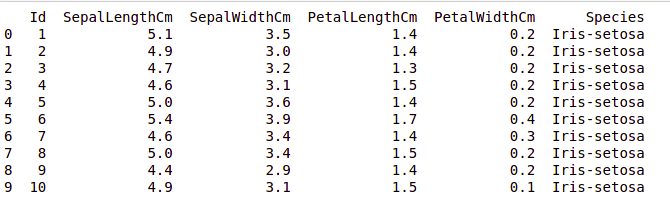

**StandardScaler** is used for feature scaling by standardizing numerical values.

It transforms the data so that it has:

Mean (μ) = 0

Standard deviation (σ) = **1**

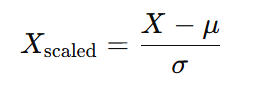

In [ ]:

# Create synthetic data
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, n_informative=15, random_state=42)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data for better convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


fit_transform(X_train) performs two operations:

1. **fit(X_train)**: Computes the mean (μ) and standard deviation (σ) of each feature in X_train.

2. **transform(X_train)**: Uses the computed μ and σ to transform X_train using the standardization formula.

**transform(X_test)**: This ensures consistency in data transformation between training and testing datasets.


## Step 3: Build the Feedforward Neural Network
We define a simple Feedforward Neural Network with the following architecture:
- **Input Layer** – 64 neurons, ReLU activation.
- **Hidden Layer** – 32 neurons, ReLU activation.
- **Output Layer** – 1 neuron, Sigmoid activation (for binary classification).


In [ ]:

# Define the model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer with 64 neurons
    layers.Dense(32, activation='relu'),                                     # Hidden layer with 32 neurons
    layers.Dense(1, activation='sigmoid')                                    # Output layer for binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



## Step 4: Compile the Model
Compile the model with:
- **Adam** optimizer – Efficient for deep learning.
- **Binary Crossentropy** loss – Suitable for binary classification.
- **Accuracy** – To measure the model’s performance.


* Adam optimization is a stochastic gradient descent method that is based on adaptive estimation of first-order and second-order moments.


In [ ]:

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


The compile method in TensorFlow Keras is used to configure the model before training. It specifies:

* **Optimizer** – How the model updates weights.

* **Loss Function** – What the model tries to minimize.

* **Metrics** – How the model's performance is measured.




## Step 5: Train the Model
Train the model using:
- **Epochs = 20** – Number of passes through the data.
- **Batch size = 32** – Number of samples processed before updating model weights.
- **Validation split = 0.2** – 20% of training data used for validation.


**Breakdown of Each Parameter**:
1. X_train, y_train
  * X_train: The training input data (features).

  * y_train: The corresponding labels (targets).

  * The model learns patterns from X_train to correctly predict y_train.

2. epochs=20
  * Epochs define how many times the model will go through the entire training dataset.

  * If epochs=20, the model will train on the entire dataset 20 times.

  * More epochs can lead to better learning but may also cause overfitting.

3. batch_size=32

* The model updates its weights after processing a subset (batch) of 32 samples.

* If batch_size=32, then:

  * If X_train has 10,000 samples, each epoch runs:

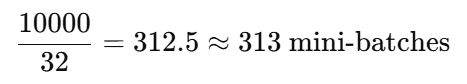

  * A larger batch size leads to more stable updates but requires more memory.

  * A smaller batch size can introduce noise in updates but may generalize better.

4. validation_split=0.2
* Splits 20% of X_train and y_train as validation data.

* The model will train on 80% of the data and evaluate on the remaining 20% at the end of each epoch.

* Helps monitor overfitting by checking model performance on unseen validation data.



In [ ]:

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5528 - loss: 0.6788 - val_accuracy: 0.7437 - val_loss: 0.5822
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7639 - loss: 0.5668 - val_accuracy: 0.8562 - val_loss: 0.4831
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8659 - loss: 0.4586 - val_accuracy: 0.8750 - val_loss: 0.3952
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8820 - loss: 0.3829 - val_accuracy: 0.8750 - val_loss: 0.3298
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8770 - loss: 0.3218 - val_accuracy: 0.8750 - val_loss: 0.2863
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9104 - loss: 0.2764 - val_accuracy: 0.9000 - val_loss: 0.2550
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9371 - loss: 0.2271 - val_accuracy: 0.9000 - val_loss: 0.2302
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9295 - loss: 0.1983 - val_accuracy: 0.9062 - val_los


## Step 6: Evaluate the Model
Evaluate the model's performance on the test set.


In [ ]:

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9104 - loss: 0.2242  
Test Loss: 0.2193, Test Accuracy: 0.9050



## Step 7: Make Predictions
Generate predictions and convert them to binary class labels.


In [ ]:

# Generate predictions
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 



## Step 8: Save the Model
Save the trained model to an H5 file.


In [ ]:

# Save the model
model.save('feedforward_nn.h5')



## Step 9: Load the Model (Optional)
Load the saved model for future use.


In [ ]:

# Load the model (Optional)
loaded_model = tf.keras.models.load_model('feedforward_nn.h5')
